--- LINEAR REGRESSION ---
MSE: 0.4498665636985056
R2 Score: 0.9085816578532504


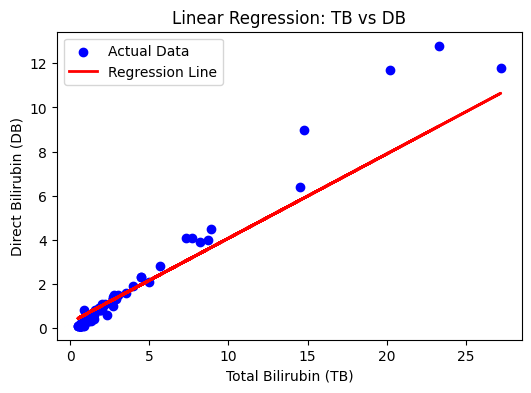


--- LOGISTIC REGRESSION ---
Accuracy: 0.6551724137931034


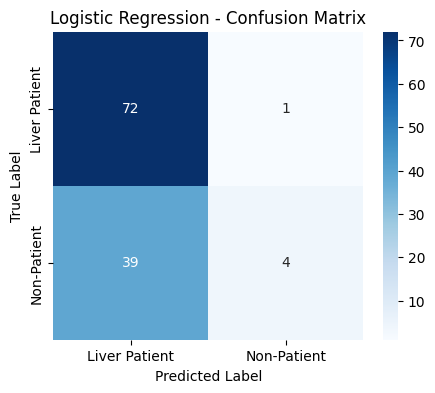

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler, LabelEncoder

# 1. Data Loading and Preprocessing
df = pd.read_csv("/content/sample_data/Indian Liver Patient Dataset (ILPD).csv").dropna()
df['Gender'] = LabelEncoder().fit_transform(df['Gender'])

print("--- LINEAR REGRESSION ---")
# Predicting DB (Direct Bilirubin) from TB (Total Bilirubin)
X_lin = df[['TB']]
y_lin = df['DB']
X_train_L, X_test_L, y_train_L, y_test_L = train_test_split(X_lin, y_lin, test_size=0.2, random_state=42)

lin_model = LinearRegression()
lin_model.fit(X_train_L, y_train_L)
y_pred_L = lin_model.predict(X_test_L)

print("MSE:", mean_squared_error(y_test_L, y_pred_L))
print("R2 Score:", r2_score(y_test_L, y_pred_L))

# Visualizing Linear Regression
plt.figure(figsize=(6, 4))
plt.scatter(X_test_L, y_test_L, color='blue', label='Actual Data')
plt.plot(X_test_L, y_pred_L, color='red', linewidth=2, label='Regression Line')
plt.title("Linear Regression: TB vs DB")
plt.xlabel("Total Bilirubin (TB)")
plt.ylabel("Direct Bilirubin (DB)")
plt.legend()
plt.show()

print("\n--- LOGISTIC REGRESSION ---")
# Predicting Selector class
X = df.drop('Selector', axis=1)
y = df['Selector']
X_scaled = StandardScaler().fit_transform(X)
X_train_LR, X_test_LR, y_train_LR, y_test_LR = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

log_model = LogisticRegression()
log_model.fit(X_train_LR, y_train_LR)
y_pred_LR = log_model.predict(X_test_LR)

print("Accuracy:", accuracy_score(y_test_LR, y_pred_LR))

# Visualizing Logistic Regression Evaluation Matrix (Confusion Matrix)
cm = confusion_matrix(y_test_LR, y_pred_LR)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Liver Patient', 'Non-Patient'], yticklabels=['Liver Patient', 'Non-Patient'])
plt.title('Logistic Regression - Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

Naïve Bayes Accuracy: 0.5862068965517241
Decision Tree Accuracy: 0.5862068965517241


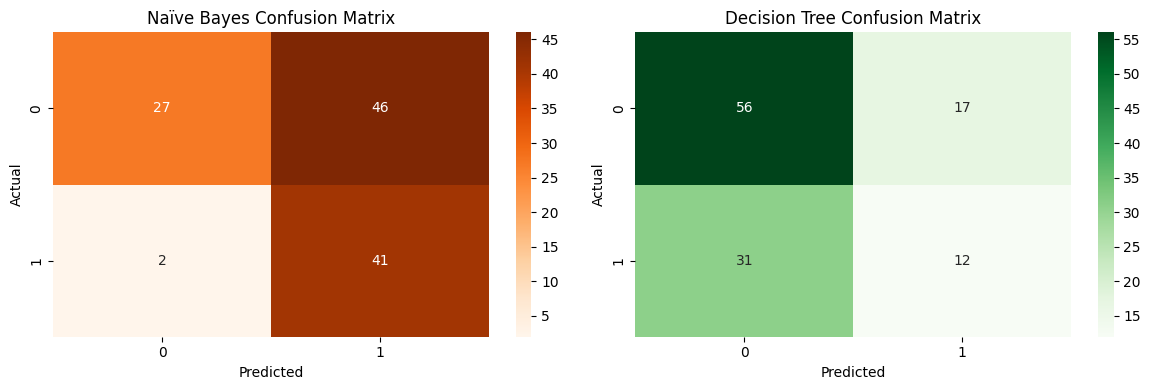

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier

# Assuming X_train_LR, X_test_LR, y_train_LR, y_test_LR are already loaded from previous experiment

# 1. Naïve Bayes
nb_model = GaussianNB()
nb_model.fit(X_train_LR, y_train_LR)
nb_preds = nb_model.predict(X_test_LR)
print("Naïve Bayes Accuracy:", accuracy_score(y_test_LR, nb_preds))

# 2. Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_LR, y_train_LR)
dt_preds = dt_model.predict(X_test_LR)
print("Decision Tree Accuracy:", accuracy_score(y_test_LR, dt_preds))

# Visualizing Evaluation Matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(confusion_matrix(y_test_LR, nb_preds), annot=True, fmt='d', cmap='Oranges', ax=axes[0])
axes[0].set_title('Naïve Bayes Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(confusion_matrix(y_test_LR, dt_preds), annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Decision Tree Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

KNN Accuracy: 0.6120689655172413
SVM Accuracy: 0.6293103448275862


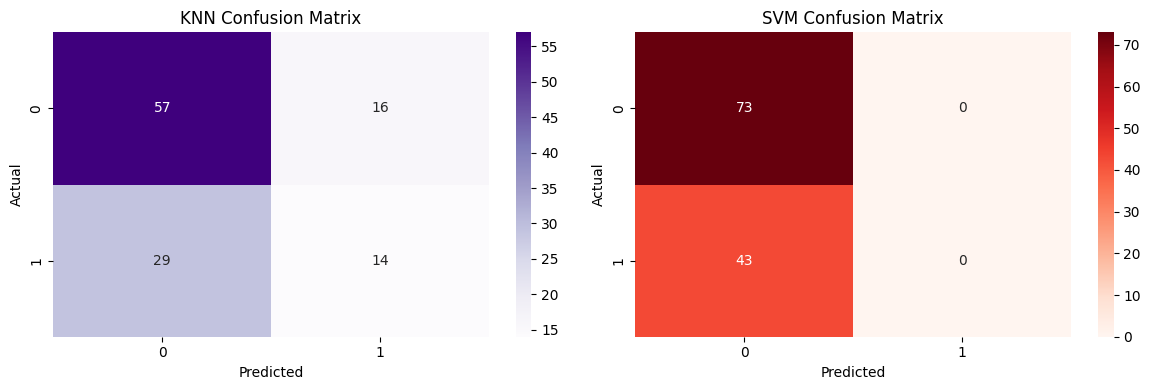

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# 1. K-Nearest Neighbors
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_LR, y_train_LR)
knn_preds = knn_model.predict(X_test_LR)
print("KNN Accuracy:", accuracy_score(y_test_LR, knn_preds))

# 2. Support Vector Machine
svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train_LR, y_train_LR)
svm_preds = svm_model.predict(X_test_LR)
print("SVM Accuracy:", accuracy_score(y_test_LR, svm_preds))

# Visualizing Evaluation Matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(confusion_matrix(y_test_LR, knn_preds), annot=True, fmt='d', cmap='Purples', ax=axes[0])
axes[0].set_title('KNN Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(confusion_matrix(y_test_LR, svm_preds), annot=True, fmt='d', cmap='Reds', ax=axes[1])
axes[1].set_title('SVM Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

Random Forest (Bagging) Accuracy: 0.6552
AdaBoost (Boosting) Accuracy: 0.6121
Stacking Classifier Accuracy: 0.6552


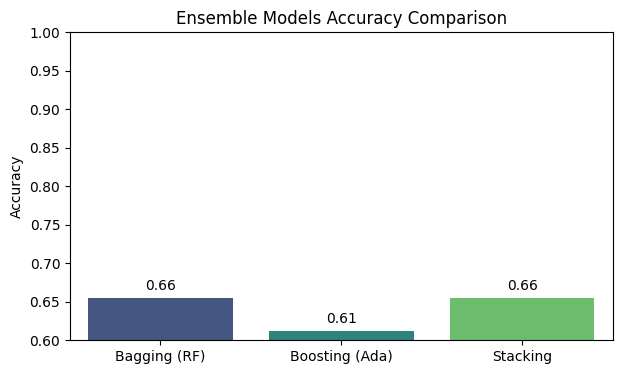

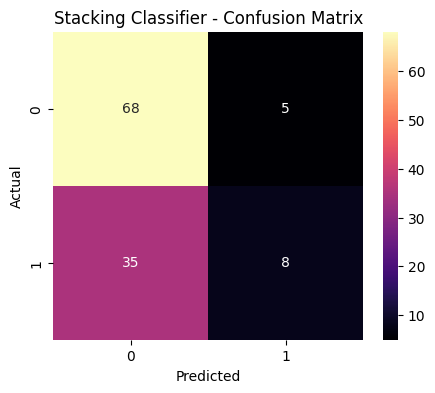

In [ ]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, StackingClassifier

# 1. Bagging (Random Forest)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_LR, y_train_LR)
rf_preds = rf_model.predict(X_test_LR)
rf_acc = accuracy_score(y_test_LR, rf_preds)

# 2. Boosting (AdaBoost)
ada_model = AdaBoostClassifier(n_estimators=100, random_state=42)
ada_model.fit(X_train_LR, y_train_LR)
ada_preds = ada_model.predict(X_test_LR)
ada_acc = accuracy_score(y_test_LR, ada_preds)

# 3. Stacking Classifier
base_learners = [
    ('rf', RandomForestClassifier(n_estimators=50, random_state=42)),
    ('knn', KNeighborsClassifier(n_neighbors=5))
]
stack_model = StackingClassifier(estimators=base_learners, final_estimator=LogisticRegression())
stack_model.fit(X_train_LR, y_train_LR)
stack_preds = stack_model.predict(X_test_LR)
stack_acc = accuracy_score(y_test_LR, stack_preds)

print(f"Random Forest (Bagging) Accuracy: {rf_acc:.4f}")
print(f"AdaBoost (Boosting) Accuracy: {ada_acc:.4f}")
print(f"Stacking Classifier Accuracy: {stack_acc:.4f}")

# Visualization: Accuracy Comparison
models = ['Bagging (RF)', 'Boosting (Ada)', 'Stacking']
accuracies = [rf_acc, ada_acc, stack_acc]

plt.figure(figsize=(7, 4))
sns.barplot(x=models, y=accuracies, hue=models, palette='viridis', legend=False)
plt.title('Ensemble Models Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0.6, 1.0) # Adjust based on your data output
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center')
plt.show()

# Stacking Confusion Matrix
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test_LR, stack_preds), annot=True, fmt='d', cmap='magma')
plt.title('Stacking Classifier - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()